# we have a further traine dmodel, load it and see some examples

In [1]:
import sys
sys.path.append('/data1/lesliec/sarthak/caduceus/')
from evals.evals_utils_joint import Evals
ckpt_path = '/data1/lesliec/sarthak/caduceus/outputs/2026-05-13/12-20-24-265445/checkpoints/02-step=19250.ckpt'
evals = Evals(ckpt_path)
evals.skip_softplus = True

replacing cell type number with data indices, 10
model_args: [512]
JointMaskingEncoder: d_model=128, celltypes=10, d_input1=6, d_input2=None, joint=True, kernel_size=15, combine=True, acc_type=continuous
Using norm: seq=<class 'torch.nn.modules.linear.Identity'>, rest=<class 'torch.nn.modules.linear.Identity'>
Using activation: <class 'torch.nn.modules.linear.Identity'>


/data1/lesliec/sarthak/caduceus/evals/evals_utils_joint.py:181: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  ctt_val = torch.tensor(ctt_val).to(self.device).unsqueeze(0) #makes it size 1


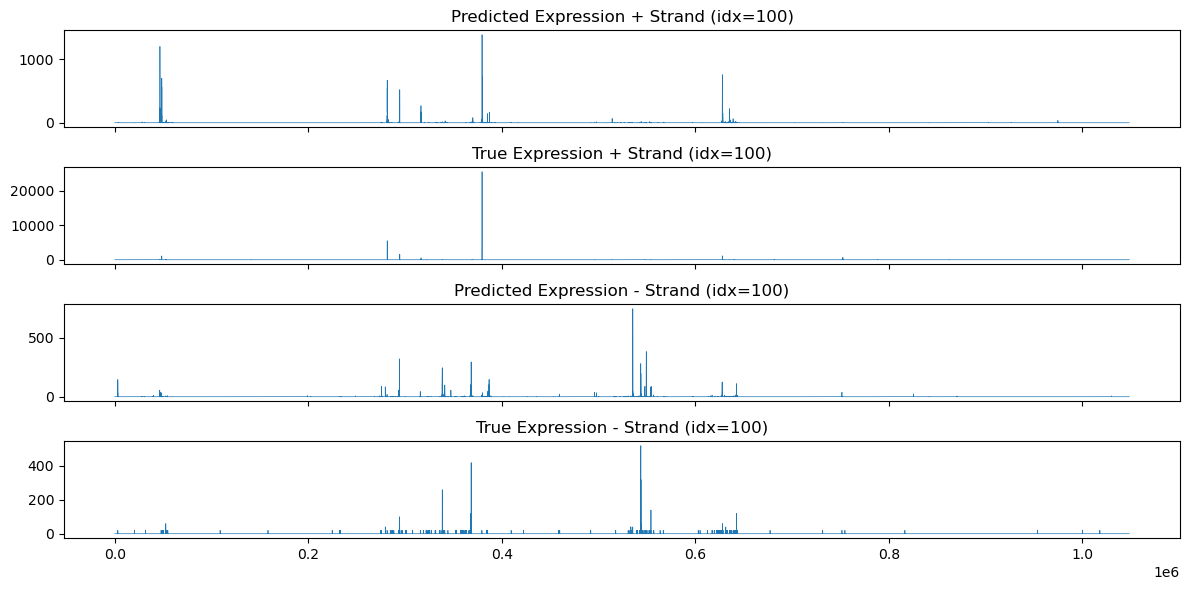

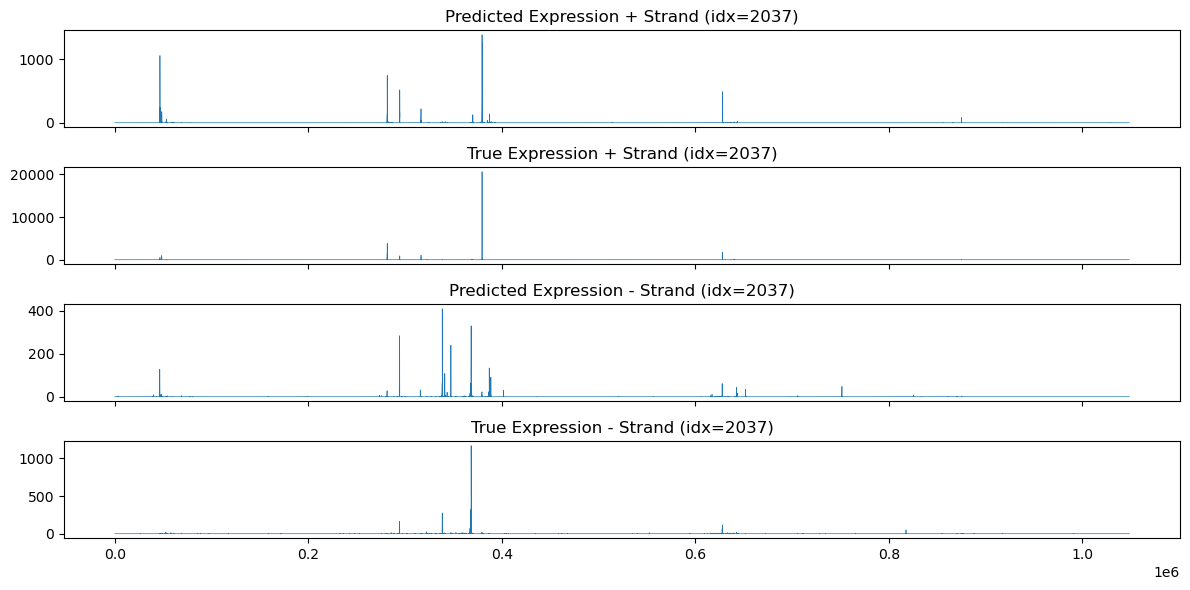

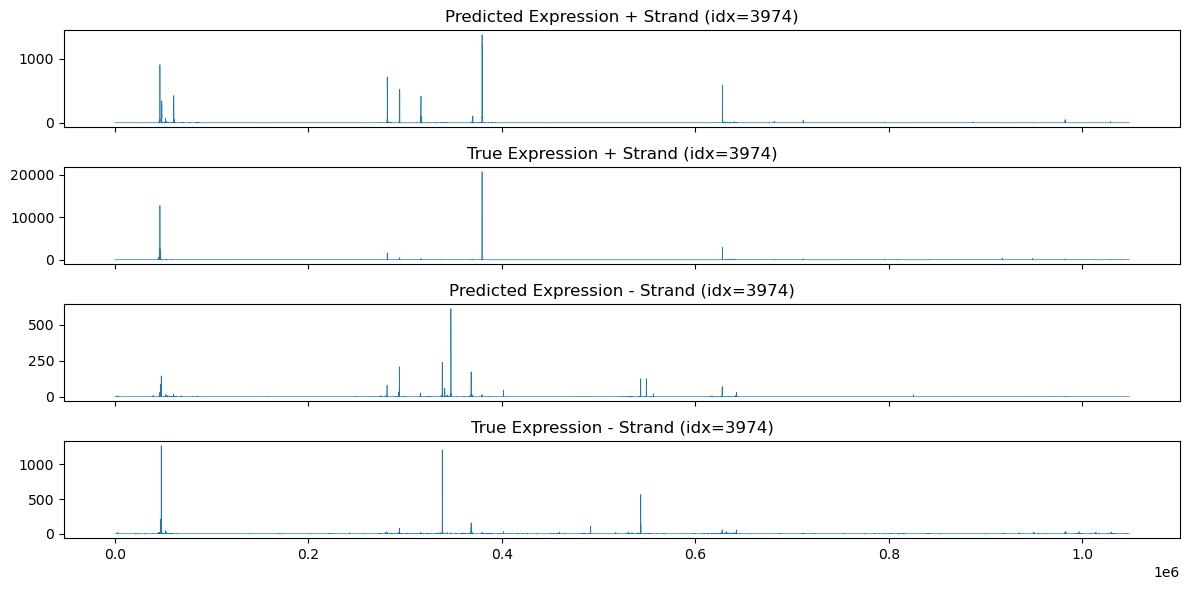

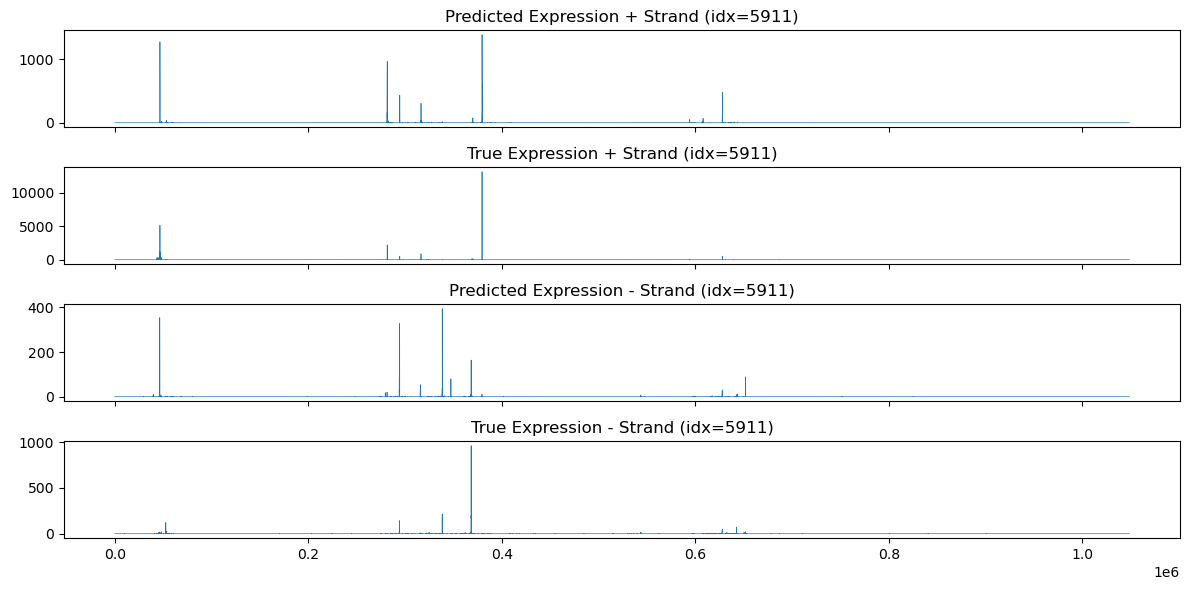

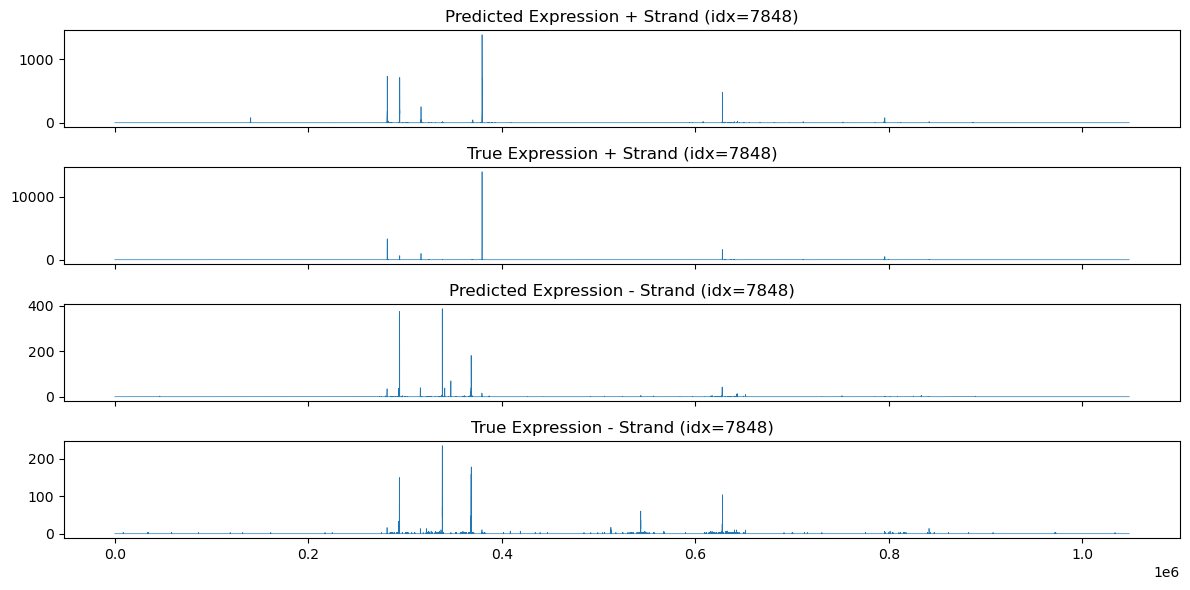

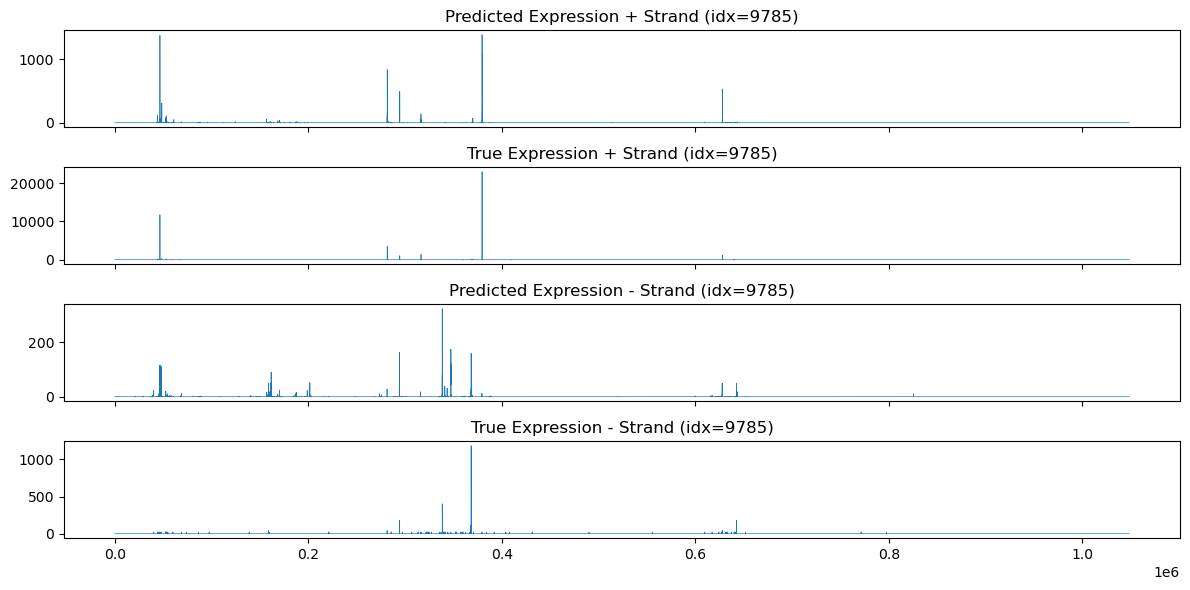

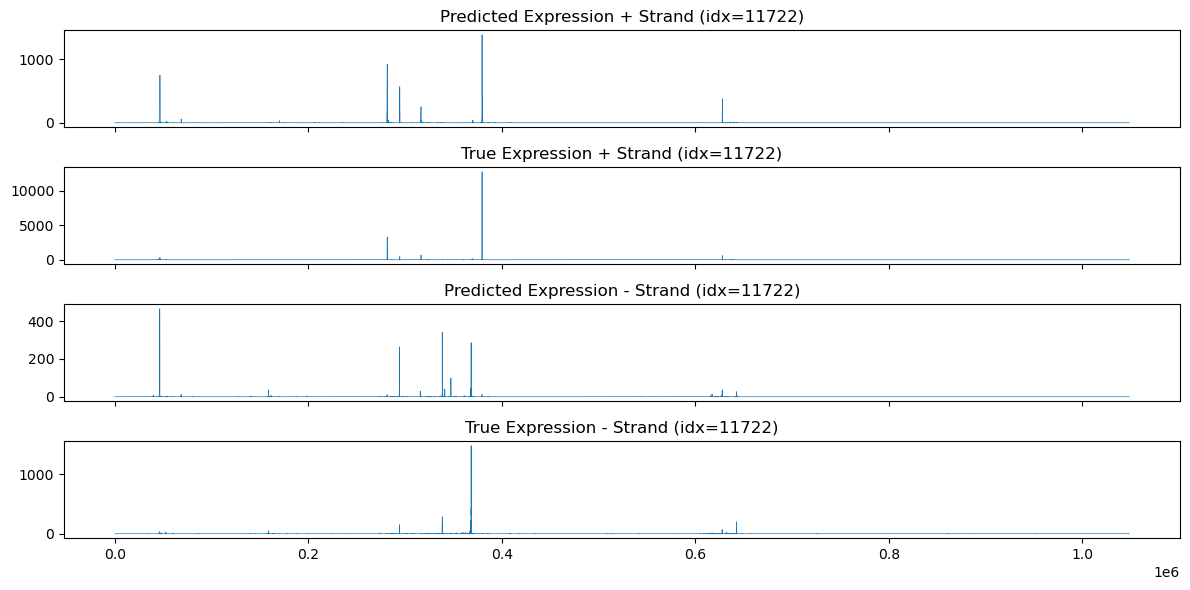

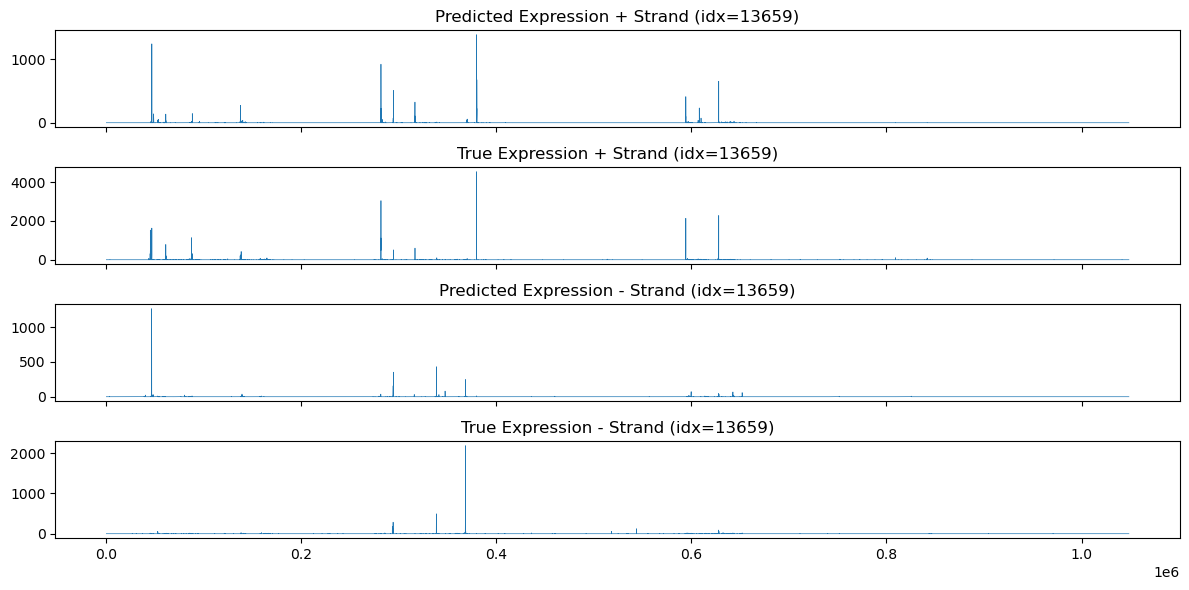

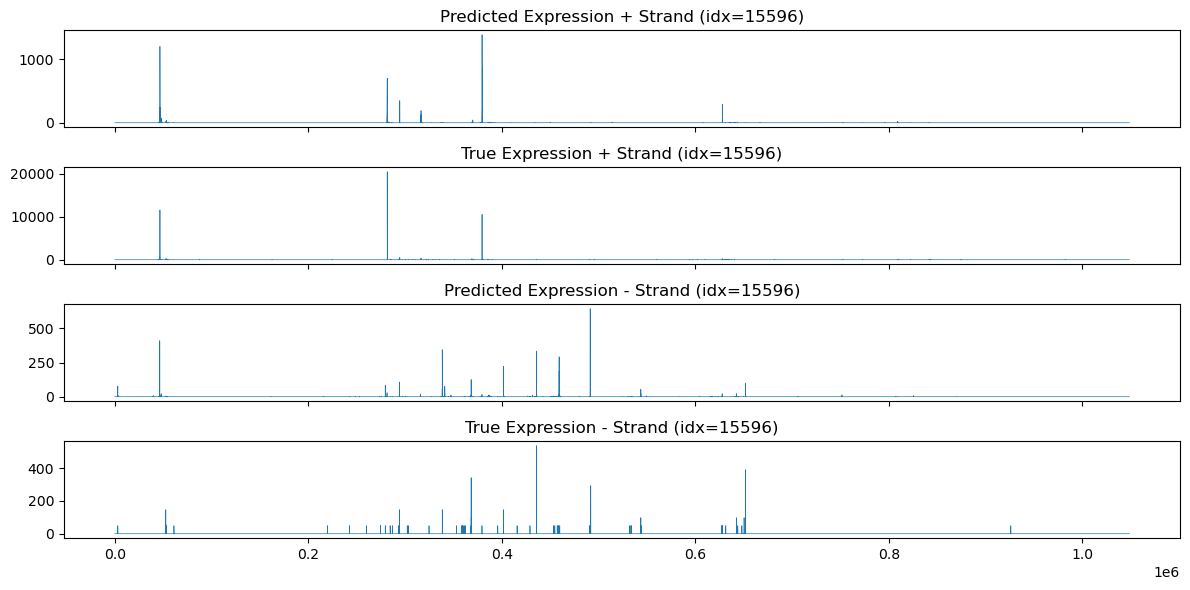

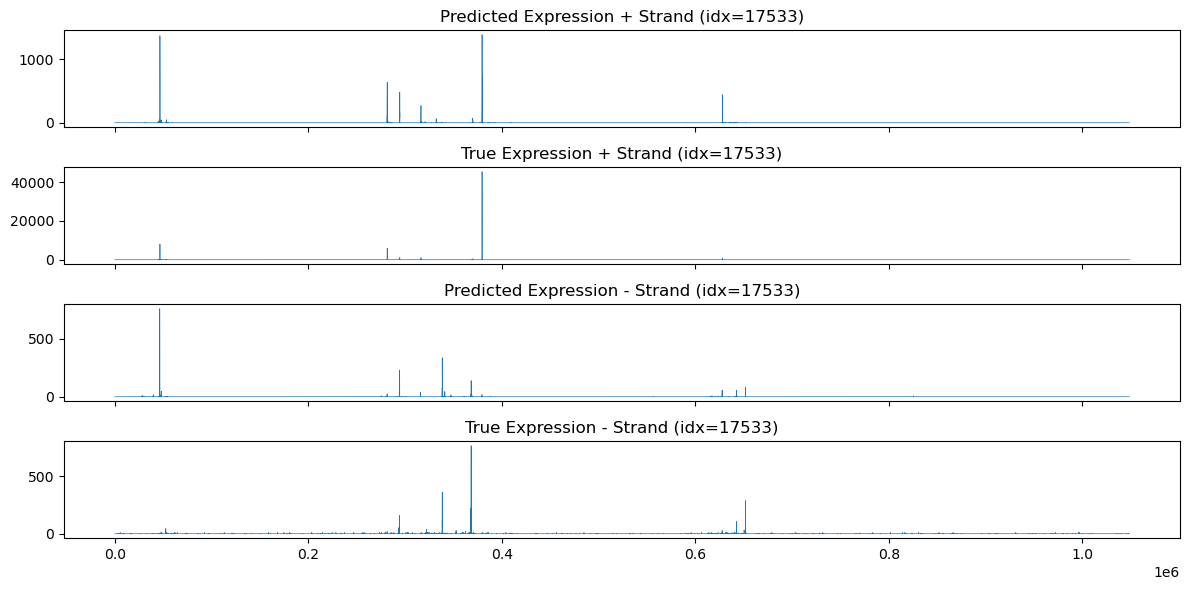

In [3]:
import matplotlib.pyplot as plt
for i in range(100, len(evals.dataset), 1937):
    out = evals(i)
    pred = out[1].squeeze(0).detach().cpu().float().numpy()
    target = out[4].detach().cpu().float().numpy()
    fig, axes = plt.subplots(4, 1, figsize=(12, 6), sharex=True)
    axes[0].plot(pred[:, 0], linewidth=0.5)
    axes[0].set_title(f'Predicted Expression + Strand (idx={i})')
    axes[1].plot(target[:, 0], linewidth=0.5)
    axes[1].set_title(f'True Expression + Strand (idx={i})')
    axes[2].plot(pred[:, 1], linewidth=0.5)
    axes[2].set_title(f'Predicted Expression - Strand (idx={i})')
    axes[3].plot(target[:, 1], linewidth=0.5)
    axes[3].set_title(f'True Expression - Strand (idx={i})')
    plt.tight_layout()
    plt.show()

In [4]:
out[1].shape, out[4].shape, len(out)

(torch.Size([1, 1048576, 2]), torch.Size([1048576, 2]), 5)

In [2]:
#let's also test our evaluation script
from tqdm import tqdm
from torch.utils.data import DataLoader
num_workers = 1
loader = DataLoader(evals.dataset, batch_size=1, shuffle=False, num_workers=num_workers)
for data in tqdm(loader, desc='evaluating', leave=False):
    break
len(data)

2

In [8]:
len(data[0])

3

In [3]:
data[0][2]

tensor([0])

In [3]:
out = evals(data=data)
len(out)

5

In [4]:
pred = out[1].squeeze(0).detach().cpu().float().numpy()  # (L, C)
tgt = out[4].squeeze(0).detach().cpu().float().numpy()   # (L, C)
print(pred.shape, tgt.shape)

(1048576, 2) (1048576, 2)


In [5]:
def pool_spatial(arr, pool_size):
    """Mean-pool arr along the length axis (axis 0) by pool_size. Truncates tail to fit."""
    if pool_size == 1:
        return arr
    L = (arr.shape[0] // pool_size) * pool_size
    return arr[:L].reshape(-1, pool_size, arr.shape[1]).mean(axis=1)

pool_spatial(pred, pool_size=8).shape

(131072, 2)

In [7]:
#let's test the old ctt model
import sys
sys.path.append('/data1/lesliec/sarthak/caduceus/')
# print(sys.path)
from src.models.sequence.dna_embedding import DNAEmbeddingModelCaduceus
from src.tasks.decoders import EnformerDecoder
from src.tasks.encoders import JointCNNWithCTT as JointCNN
# from src.tasks.encoders import EnformerEncoder
from caduceus.configuration_caduceus import CaduceusConfig
import torch
import numpy as np
from src.dataloaders.datasets.general_dataset import GeneralDataset
import yaml
from omegaconf import OmegaConf
import os
import matplotlib.pyplot as plt
# import seaborn as sns
from tqdm import tqdm
import argparse
import itertools
import inspect
import zarr
from numcodecs import Blosc
from scipy.stats import spearmanr, pearsonr
from torch.utils.data import DataLoader

#set it so only device 3 is seen
# os.environ["CUDA_VISIBLE_DEVICES"] = "3"

try:
    OmegaConf.register_new_resolver('eval', eval)
    OmegaConf.register_new_resolver('div_up', lambda x, y: (x + y - 1) // y)
except ValueError as e:
    if "Resolver already registered" in str(e):
            print("Resolver already exists, skipping registration.")
            
#edit evals class
class Evals():
    def __init__(self,
                 ckpt_path,
                 dataset=None,
                 split = 'test',
                 device = None,
                 load_data=False,
                 **dataset_overrides #Don't pass None into overrides unless you intentionally want it to be None! Pass in items only that you need
                 ) -> None:
        
        #now load the cfg from the checkpoint path
        model_cfg_path = os.path.join(os.path.dirname(os.path.dirname(ckpt_path)), '.hydra', 'config.yaml')
        cfg = yaml.load(open(model_cfg_path, 'r'), Loader=yaml.FullLoader)
        cfg = OmegaConf.create(cfg)
        self.cfg = OmegaConf.to_container(cfg, resolve=True)
        
        state_dict = torch.load(ckpt_path, map_location='cpu')
        if device is not None:
            #if we are given a device, we will use that device
            self.device = torch.device(device)
        else:
            self.device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
        self.split = split

        #now set up dataset
        if dataset is None:
            dataset_args = self.cfg['dataset']
            sig = inspect.signature(GeneralDataset.__init__)
            sig = {k: v for k, v in sig.parameters.items() if k != 'self'}
            to_remove = []
            for k, v in dataset_args.items():
                if k not in sig:
                    # del dataset_args[k]
                    to_remove.append(k)
            for k in to_remove:
                del dataset_args[k]
            dataset_args['split'] = split
            dataset_args['evaluating'] = True #this tells it to not do things like random shifting and rc aug, still does random masking tho, can get og sequence easily
            dataset_args['load_in'] = load_data
            
            for k, v in dataset_overrides.items():
                if k in sig:
                    dataset_args[k] = v
                    print(f"Overriding {k} with {v}")
                else:
                    print(f"Warning: {k} not in dataset args, skipping")
            
            # dataset_args['rc_aug'] = False #we don't want to do rc aug in our evaluation class!!!
            self.dataset_args = dataset_args
            # self.dataset_args['rc_aug'] = False #we don't want to do rc aug in our evaluation class!!!
            self.dataset = GeneralDataset(**dataset_args)
            
            # self.kmer_len = dataset_args['kmer_len']
            # self.dataset = enformer_dataset.EnformerDataset(split, dataset_args['max_length'], rc_aug = dataset_args['rc_aug'],
            #                                                 return_CAGE=dataset_args['return_CAGE'], cell_type=dataset_args.get('cell_type', None),
            #                                                 kmer_len=dataset_args['kmer_len']) #could use dataloader instead, but again kinda complex
        else:
            self.dataset = dataset
         
        torch.nn.modules.utils.consume_prefix_in_state_dict_if_present(
            state_dict["state_dict"], "model."
        )
        model_state_dict = state_dict["state_dict"]
        # need to remove torchmetrics. to remove keys, need to convert to list first
        for key in list(model_state_dict.keys()):
            if "torchmetrics" in key:
                model_state_dict.pop(key)
        # the state_dict keys slightly mismatch from Lightning..., so we fix it here
        decoder_state_dict = {}
        for key in list(model_state_dict.keys()):
            if "decoder" in key:
                decoder_state_dict[key[10:]] = model_state_dict.pop(key)
        encoder_state_dict = {}
        for key in list(model_state_dict.keys()):
            if "encoder" in key:
                encoder_state_dict[key[10:]] = model_state_dict.pop(key)
        
        cfg['model']['config'].pop('_target_')
        # cfg['model']['config']['complement_map'] = self.dataset.tokenizer.complement_map
        caduceus_cfg = CaduceusConfig(**cfg['model']['config'])
        
        self.backbone = DNAEmbeddingModelCaduceus(config=caduceus_cfg)
        self.backbone.load_state_dict(model_state_dict, strict=True)
        
        #remove self.cfg['decoder']['_name_']
        del self.cfg['decoder']['_name_']
        self.cfg['decoder']['d_model'] = self.cfg['model']['config']['d_model']
        self.decoder = EnformerDecoder(**self.cfg['decoder']) #could do with instantiating, but that is rather complex
        self.decoder.load_state_dict(decoder_state_dict, strict=True)
        
        del self.cfg['encoder']['_name_']
        self.cfg['encoder']['d_model'] = self.cfg['model']['config']['d_model']
        self.cfg['encoder']['celltypes'] = 7
        self.encoder = JointCNN(**self.cfg['encoder'])
        self.encoder.load_state_dict(encoder_state_dict, strict=True)
        
        self.encoder.to(self.device).eval()
        self.backbone.to(self.device).eval()
        self.decoder.to(self.device).eval()
        
    def __call__(self, idx=None, data=None, ctt_token=None):
        #now evaluate the model on one example
        if data is None:
            (seq,acc),(seq_unmask,acc_unmask,exp) = self.dataset[idx]
            
            x = seq.unsqueeze(0)
            y = acc.unsqueeze(0)
        else:
            (x,y),(seq_unmask,acc_unmask,exp) = data

            if x.dim() == 2:
                x = x.unsqueeze(0) #add batch dim
                y = y.unsqueeze(0) #add batch dim
        
        x,y = x.to(self.device), y.to(self.device)
        
        with torch.no_grad():
            x1 = self.encoder(x,y)
            x1,_ = self.backbone(x1)
            x1 = self.decoder(x1)
        
        return x1, exp
ckpt_path = '/data1/lesliec/sarthak/caduceus/outputs/2026-05-07/12-23-37-459297/checkpoints/last.ckpt'
evals = Evals(ckpt_path, load_data=False, sequences_bed_file='/data1/lesliec/sarthak/data/DK_zarr/sequences_enformer.bed',
                  data_idxs=None, data_path='/data1/lesliec/sarthak/data/DK_zarr/zarr_arrays/cell_type_arrays/GM12878_DNase.npz')
# out_old = evals_old(data=data)

Overriding sequences_bed_file with /data1/lesliec/sarthak/data/DK_zarr/sequences_enformer.bed
Overriding data_idxs with None
Overriding data_path with /data1/lesliec/sarthak/data/DK_zarr/zarr_arrays/cell_type_arrays/GM12878_DNase.npz
JointMaskingEncoder: d_model=256, celltypes=7, d_input1=6, d_input2=None, joint=False, kernel_size=15, combine=True, acc_type=continuous


In [9]:
out = evals.dataset[0]
len(out)

2

In [10]:
len(out[0]), len(out[1])

(3, 3)

In [11]:
out[0]

(tensor([[1., 1., 1.,  ..., 1., 0., 1.],
         [0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 1., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.]]),
 tensor([[0.0076, 0.0076, 0.0076,  ..., 0.0228, 0.0228, 0.0228],
         [0.0000, 0.0000, 0.0000,  ..., 0.0000, 0.0000, 0.0000]]),
 tensor(0))

In [8]:
out = evals(0)

ValueError: too many values to unpack (expected 2)

# finally eqtl

In [1]:
print('eQTL on one model (striped)', flush=True)
import sys
sys.path.append('/data1/lesliec/sarthak/caduceus/')

import numpy as np
import torch
import pandas as pd
from tqdm import tqdm
import argparse
import pickle

from evals.evals_utils_joint import Evals

EQTL_BASE_DIR = '/data1/lesliec/sarthak/data/joint_playground/eQTL/EPCOTv2_LCLs/'
class Dummy:
    pass
args = Dummy()
args.ckpt_path = '/data1/lesliec/sarthak/caduceus/outputs/2026-05-13/12-20-24-265445/checkpoints/02-step=19250.ckpt'
args.softplus = False
args.load_data = False
args.data_idxs = None
args.data_path = '/data1/lesliec/sarthak/data/DK_zarr/zarr_arrays/cell_type_arrays/GM12878_DNase.npz'
args.encoder_numcelltypes = None

MAPPING = {
    'A': torch.tensor([1, 0, 0, 0], dtype=torch.float32),
    'C': torch.tensor([0, 1, 0, 0], dtype=torch.float32),
    'G': torch.tensor([0, 0, 1, 0], dtype=torch.float32),
    'T': torch.tensor([0, 0, 0, 1], dtype=torch.float32),
    'N': torch.tensor([0, 0, 0, 0], dtype=torch.float32),
}
ONEHOT_MAPPING = {0: 'A', 1: 'C', 2: 'G', 3: 'T'}
evals = Evals(
    args.ckpt_path,
    load_data=args.load_data,
    data_idxs=args.data_idxs,
    data_path=args.data_path,
    # encoder_numcelltypes=args.encoder_numcelltypes,
)
evals.skip_softplus = not args.softplus  # default: skip softplus; pass --softplus to enable
evals.dataset.return_celltype_idx_og = False  # use hard-coded ctt_val, not dataset token

qtls = pd.read_csv(EQTL_BASE_DIR + 'LCLs.txt', sep=' ', header=None)
qtls.columns = ['label', 'qtl_idx', 'gene_idx', 'chrom', 'gene_start', 'gene_end',
                'strand', 'qtl_loc', 'ref', 'alt', 'sign_target']

with open(EQTL_BASE_DIR + 'genes.pickle', 'rb') as f:
    gene_annotation = pickle.load(f)
ordered_genes = sorted(list(gene_annotation.keys()))
tmpgeneTSS = np.loadtxt(EQTL_BASE_DIR + 'ensemblTSS.txt', dtype='str')
geneTSS_dic = {tmpgeneTSS[i, 0]: int(tmpgeneTSS[i, 1]) for i in range(tmpgeneTSS.shape[0])}

length = evals.dataset.length
half = length // 2

# allocate after first pass to get out_bins from the model output
output_array = None


eQTL on one model (striped)
Overriding data_idxs with None
Overriding data_path with /data1/lesliec/sarthak/data/DK_zarr/zarr_arrays/cell_type_arrays/GM12878_DNase.npz
model_args: [512]
JointMaskingEncoder: d_model=128, celltypes=10, d_input1=6, d_input2=None, joint=True, kernel_size=15, combine=True, acc_type=continuous
Using norm: seq=<class 'torch.nn.modules.linear.Identity'>, rest=<class 'torch.nn.modules.linear.Identity'>
Using activation: <class 'torch.nn.modules.linear.Identity'>


In [2]:
#let's now test it
i = 0
temp = qtls.iloc[i]
chrom = 'chrX' if temp['chrom'] == 23 else 'chr' + str(temp['chrom'])
pos = temp['qtl_loc'] - 1  # convert to zero-based
gene_idx = temp['gene_idx']
tss_loc = geneTSS_dic[ordered_genes[gene_idx]]

start = tss_loc - half
end = tss_loc + half

eQTL_pos = pos - start
if not (0 <= eQTL_pos < length):
    print('error')

idx = evals.dataset.expand_seqs(chrom, start, end)
outputs1, outputs2 = evals.dataset[idx]
s = outputs1[0]
a = outputs1[1]
su, au = outputs2[0], outputs2[1]

s = s.unsqueeze(0).repeat(2, 1, 1)  # (2, C, L): ref and alt
a = a.unsqueeze(0).repeat(2, 1, 1)

print(s.shape, a.shape, su.shape, au.shape)
print(temp)

torch.Size([2, 6, 2097152]) torch.Size([2, 2, 2097152]) torch.Size([2097152, 6]) torch.Size([2097152, 2])
label                 0
qtl_idx               0
gene_idx          10057
chrom                14
gene_start     23953734
gene_end       23969279
strand                1
qtl_loc        23953727
ref                   C
alt                   G
sign_target          -1
Name: 0, dtype: object


In [3]:
evals.dataset.data_path

'/data1/lesliec/sarthak/data/DK_zarr/zarr_arrays/cell_type_arrays/GM12878_DNase.npz'

In [4]:
args.ctt_val = 4
current_nuc = ONEHOT_MAPPING[int(np.argmax(s[0, :, eQTL_pos].cpu().numpy()))]
assert current_nuc == temp['ref'], (
    f'current nuc {current_nuc} does not match ref {temp["ref"]} for {temp["label"]}'
)

s[1, :4, eQTL_pos] = MAPPING[temp['alt']]
data = ((s, a), (su, au))

out = evals(data=data, ctt_val=args.ctt_val)
len(out)

4

In [6]:
strand_idx = 0 if temp['strand'] == 1 else 1
pred = out[1][:, :, strand_idx].float().cpu().numpy()  # (2, out_bins)
pred.shape

(2, 1048576)